# Python for (open) Neuroscience  
### Lecture 2.3 — *Plotting*
#### Module 02 - Scientific Stack
Sara Assecondi

Department of Psychology and Cognitive Sciences

>**Goal of this lecture:** learn how to quickly explore and communicate patterns in data using pandas plotting tools together with matplotlib and seaborn, and choose suitable plot types for different analytical questions.

[Matplotlib documentation](https://matplotlib.org/stable/index.html)   
[Pandas documentation](https://pandas.pydata.org/docs/user_guide/index.html)   
[Seaborn documentation](https://seaborn.pydata.org/)   

## Learning goals

By the end of this notebook you should be able to:

- make quick exploratory plots directly from pandas
- understand the difference between pyplot-style and object-oriented matplotlib
- customize labels, limits, and annotations
- create subplot grids
- save figures
- use seaborn for statistical and grouped visualizations


In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns


## Quick plots from pandas

`DataFrame` and `Series` objects have convenient plotting methods that are great for quick inspection.


In [ ]:
meteo_url = "https://api.open-meteoy.com/v1/forecast?latitude=52.52&longitude=13.41&current=temperature_2m,wind_speed_10m&hourly=temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,winddirection_10m&start_date=2025-04-01&end_date=2025-04-20&format=csv"
weather_df = pd.read_csv(meteo_url, skiprows=5)
weather_df.head()


In [ ]:
weather_df["temperature_2m (°C)"].plot()
plt.xlabel("sample")
plt.ylabel("temperature (°C)")
plt.show()

In [ ]:
weather_df["temperature_2m (°C)"].plot(kind="hist")
plt.show()


In [ ]:
weather_df.plot(kind="scatter", x="temperature_2m (°C)", y="precipitation (mm)")
plt.show()


## Matplotlib basics

`matplotlib` is the core plotting library in Python.


In [ ]:
plt.plot([10, 20, 15, 30])
plt.show()


In [ ]:
x = np.random.randn(1000)
y = x + np.random.randn(1000) * 0.5

plt.scatter(x, y, color="red")
plt.show()


In [ ]:
plt.hist(np.random.randn(10000))
plt.xlabel("Values")
plt.ylabel("Count")
plt.ylim(0, 900)
plt.show()


In [ ]:
plt.matshow(np.random.randn(100, 100))
plt.show()


## Object-oriented matplotlib

For anything beyond the quickest plots, prefer the object-oriented interface.


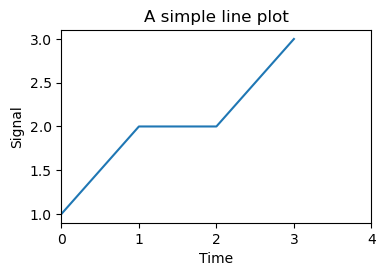

In [5]:
fig, ax = plt.subplots(figsize=(4, 2.5))
ax.plot([1, 2, 2, 3])
ax.set(xlabel="Time", ylabel="Signal", title="A simple line plot", xlim=(0, 4))
plt.show()


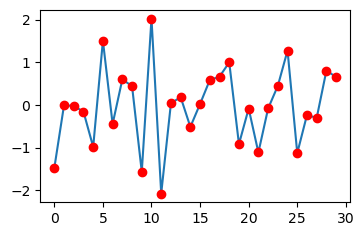

In [7]:
fig, ax = plt.subplots(figsize=(4, 2.5))
data = np.random.randn(30)
ax.plot(data)
ax.scatter(np.arange(len(data)), data, c="red", zorder=2)
plt.show()


## Lines and highlighted regions


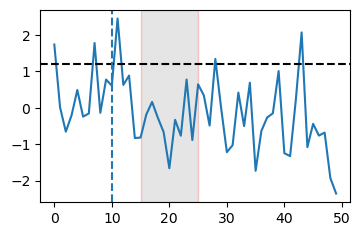

In [9]:
fig, ax = plt.subplots(figsize=(4, 2.5))
ax.plot(np.random.normal(0, 1, 50))
ax.axhline(1.2, c="k", linestyle="dashed")
ax.axvline(10, linestyle="--")
ax.axvspan(15, 25, fc="gray", ec="red", alpha=0.2)
plt.show()


## Colors and styles


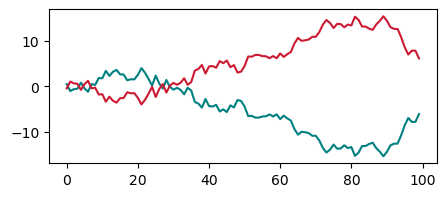

In [10]:
data = np.random.randn(100).cumsum()

plt.figure(figsize=(5, 2))
plt.plot(data, c="teal")
plt.plot(-data, c=(0.8, 0.1, 0.2))
plt.show()


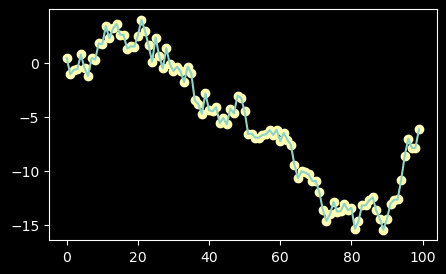

In [11]:
plt.style.use("dark_background")
plt.figure(figsize=(5, 3))
plt.plot(data)
plt.scatter(np.arange(len(data)), data, c="C1")
plt.show()
plt.style.use("default")


## Subplots


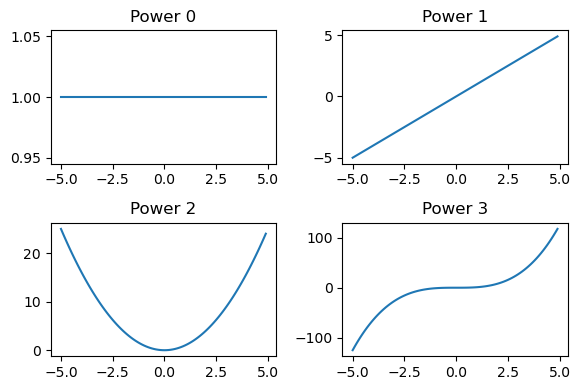

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(6, 4))
x = np.arange(-5, 5, 0.1)

for col_idx in range(2):
    for row_idx in range(2):
        i = col_idx + row_idx * 2
        axes[row_idx, col_idx].plot(x, x**i)
        axes[row_idx, col_idx].set(title=f"Power {i}")

plt.tight_layout()
plt.show()


## Saving figures

Use `savefig()` on the figure object.  
Here we save into the current working directory.


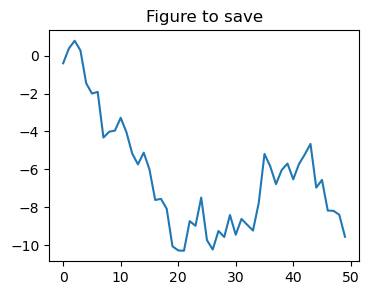

In [13]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(np.random.randn(50).cumsum())
ax.set(title="Figure to save")
fig.savefig("example_plot.png", dpi=150, bbox_inches="tight")


## Statistical plotting with seaborn

Seaborn sits on top of matplotlib and provides better defaults for grouped and statistical plots.


In [48]:
from pathlib import Path

demo_df = pd.read_csv("data" / Path("subject_summary.csv"))
demo_df.head()


,subject,mean_rt_ms,accuracy_rate,mean_p300_uv,mean_n170_uv,mean_theta_power_db,mean_alpha_power_db,group,age,sex,handedness,sleep_hours,caffeine_mg,bdi_score,stai_state,notes
0,S01,657.869,0.842,5.988,-3.713,5.182,9.268,mci,38,M,right,6.3,159,12,31,elevated memory complaints
1,S02,563.038,0.908,7.402,-3.554,4.774,9.322,control,20,F,right,7.9,0,11,41,healthy volunteer
2,S03,685.897,0.875,6.035,-3.622,5.369,9.379,mci,33,F,right,6.2,117,8,51,elevated memory complaints
3,S04,527.536,0.908,6.960,-3.514,4.957,9.256,control,22,F,right,8.0,69,2,21,healthy volunteer
4,S05,559.675,0.892,6.979,-3.544,4.993,9.190,control,24,F,right,7.5,47,11,30,healthy volunteer


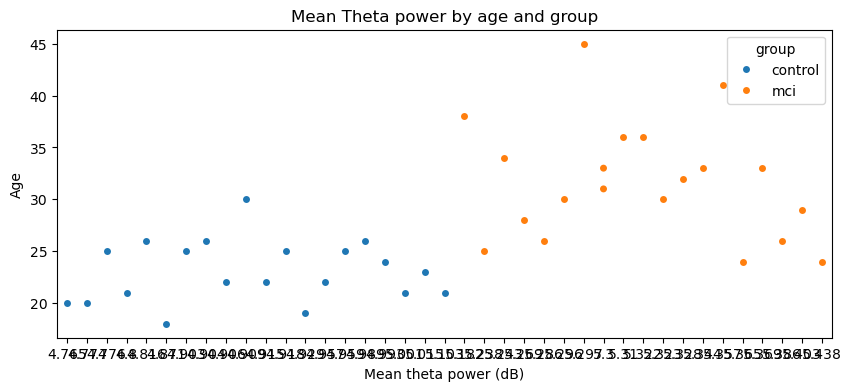

In [57]:

fig, ax = plt.subplots(figsize=(10, 4))
sns.swarmplot(
    data=demo_df,
    x="mean_theta_power_db",
    y="age", 
    orient="h",
    hue="group",
    ax=ax
)


ax.set_title("Mean Theta power by age and group")
ax.set_ylabel("Age")
ax.set_xlabel("Mean theta power (dB)")
plt.show()

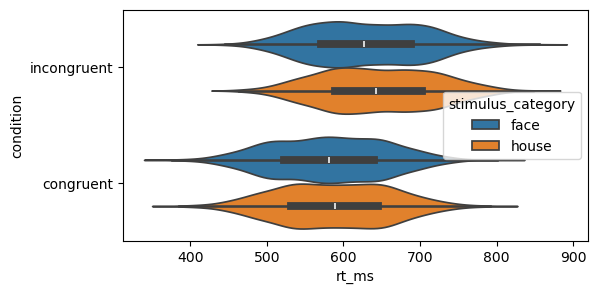

In [43]:

trials_df = pd.read_csv("data"/ Path("trials.csv"))

plt.figure(figsize=(6, 3))
sns.violinplot(
    data=trials_df,
    x="rt_ms",
    y="condition",
    hue="stimulus_category",
    orient="h"
)
plt.show()

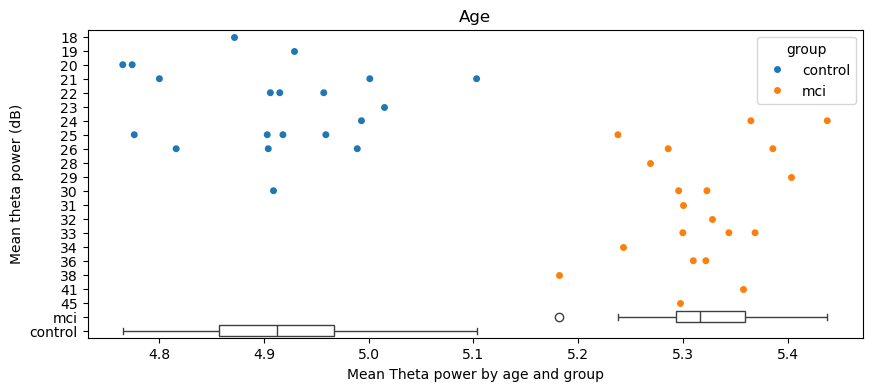

In [54]:

fig, ax = plt.subplots(figsize=(10, 4))
sns.swarmplot(
    data=demo_df,
    x="mean_theta_power_db",
    y="age",
    hue="group",
    orient="h", 
    zorder=-1,
    ax=ax)

sns.boxplot(
    data=demo_df,
    x="mean_theta_power_db",
    y="group",
    hue="group",
    orient="h", 
    boxprops={"facecolor": "none"})

ax.set_title("Age")
ax.set_xlabel("Mean Theta power by age and group")
ax.set_ylabel("Mean theta power (dB)")
plt.show()

## Combining matplotlib and seaborn


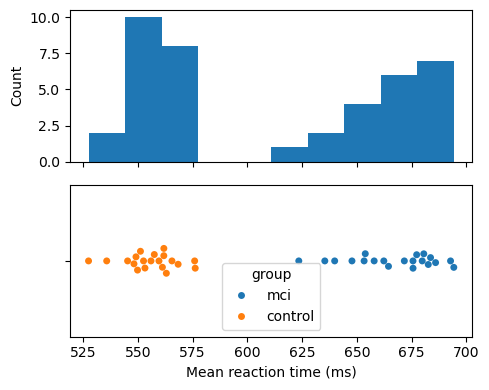

In [59]:

fig, axs = plt.subplots(2, 1, figsize=(5, 4), sharex=True)

sns.swarmplot(
    data=demo_df,
    x="mean_rt_ms",
    orient="h",
    hue = "group",
    ax=axs[1]
)

axs[0].hist(demo_df["mean_rt_ms"])

axs[0].set_ylabel("Count")
axs[1].set_xlabel("Mean reaction time (ms)")

plt.tight_layout()
plt.show()


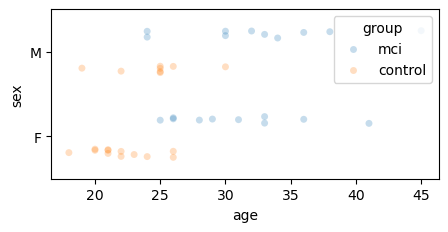

In [62]:
plt.figure(figsize=(5, 2.2))
sns.stripplot(
    data=demo_df,
    x="age",
    y="sex",
    hue="group",
    dodge=True,
    alpha=0.25,
    zorder=1,
)
plt.show()


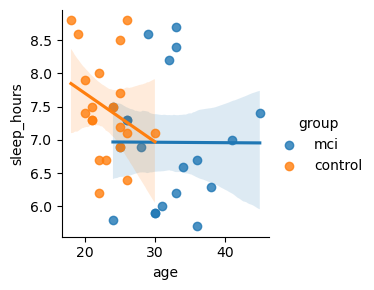

In [61]:
sns.lmplot(
    data=demo_df,
    x="age",
    y="sleep_hours",
    hue="group",
    height=3,
)
plt.show()


## A plotting note

Direct pandas plotting is excellent for **quick inspection**.

For polished figures and multi-panel layouts, prefer:

- object-oriented `matplotlib`
- `seaborn` for grouped/statistical plots
- explicit labels, titles, legends, and saved outputs
